# NIVEL MEDIO - Calidad de Datos con Funciones

Este notebook implementa el análisis de calidad de datos usando funciones reutilizables.

---

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


## Funciones de Análisis de Calidad

In [5]:
# FUNCIONES DE ANÁLISIS DE CALIDAD - INGRESOS MUNICIPALIDADES SIAF

def analizar_completitud(df):
    """Analiza datos faltantes en columnas críticas del SIAF"""
    columnas_criticas = [
        'NIVEL_GOBIERNO', 'EJECUTORA_NOMBRE',
        'DEPARTAMENTO_EJECUTORA_NOMBRE', 'RUBRO_NOMBRE',
        'MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO'
    ]
    missing_data    = df.isnull().sum()
    missing_percent = (missing_data / len(df)) * 100

    completitud = pd.DataFrame({
        'Faltantes':   missing_data,
        'Porcentaje':  missing_percent
    }).sort_values('Porcentaje', ascending=False)

    print("📌 Completitud en columnas CRÍTICAS:")
    for col in columnas_criticas:
        faltantes  = df[col].isnull().sum()
        porcentaje = (faltantes / len(df)) * 100
        estado     = "✅ OK" if porcentaje == 0 else "⚠️ REVISAR"
        print(f"   {estado} {col}: {faltantes:,} faltantes ({porcentaje:.2f}%)")

    return completitud[completitud['Faltantes'] > 0]


def analizar_exactitud(df):
    """Detecta montos presupuestales incorrectos en municipalidades"""
    df_munic = df[df['NIVEL_GOBIERNO'] == 'M'].copy()

    resultados = {
        'pia_negativos':        df_munic[df_munic['MONTO_PIA'] < 0],
        'pim_negativos':        df_munic[df_munic['MONTO_PIM'] < 0],
        'recaudado_negativos':  df_munic[df_munic['MONTO_RECAUDADO'] < 0],
        'pim_menor_pia':        df_munic[df_munic['MONTO_PIM'] < df_munic['MONTO_PIA']],
        'recaudado_mayor_2xpim': df_munic[
            df_munic['MONTO_RECAUDADO'] > df_munic['MONTO_PIM'] * 2
        ]
    }
    return resultados


def analizar_consistencia(df):
    """Verifica coherencia entre campos relacionados del SIAF"""
    df_munic = df[df['NIVEL_GOBIERNO'] == 'M'].copy()

    # Nivel gobierno: código vs nombre
    reglas_nivel = {
        'E': 'GOBIERNO NACIONAL',
        'R': 'GOBIERNOS REGIONALES',
        'M': 'GOBIERNOS LOCALES'
    }
    df_munic['NIVEL_NOMBRE_ESPERADO'] = df_munic['NIVEL_GOBIERNO'].map(
        reglas_nivel
    )
    inconsist_nivel = df_munic[
        df_munic['NIVEL_GOBIERNO_NOMBRE'] != df_munic['NIVEL_NOMBRE_ESPERADO']
    ]

    # Fuente financiamiento: código siempre con mismo nombre
    fuente_check = df_munic.groupby(
        'FUENTE_FINANCIAMIENTO'
    )['FUENTE_FINANCIAMIENTO_NOMBRE'].nunique()
    fuentes_inconsistentes = fuente_check[fuente_check > 1]

    # Rubro: código siempre con mismo nombre
    rubro_check = df_munic.groupby('RUBRO')['RUBRO_NOMBRE'].nunique()
    rubros_inconsistentes = rubro_check[rubro_check > 1]

    # Año documento vs año del archivo origen
    df_munic['ANO_ORIGEN'] = df_munic['ARCHIVO_ORIGEN'].str.extract(
        r'(\d{4})'
    ).astype(float)
    inconsist_anio = df_munic[df_munic['ANO_DOC'] != df_munic['ANO_ORIGEN']]

    return {
        'inconsist_nivel':        inconsist_nivel,
        'fuentes_inconsistentes': fuentes_inconsistentes,
        'rubros_inconsistentes':  rubros_inconsistentes,
        'inconsist_anio':         inconsist_anio
    }


def analizar_integridad(df):
    """Valida códigos y rangos de campos identificadores"""
    df_munic = df[df['NIVEL_GOBIERNO'] == 'M'].copy()

    # Construir UBIGEO de 6 dígitos
    df_munic['UBIGEO'] = (
        df_munic['DEPARTAMENTO_EJECUTORA'].astype(str).str.zfill(2) +
        df_munic['PROVINCIA_EJECUTORA'].astype(str).str.zfill(2)   +
        df_munic['DISTRITO_EJECUTORA'].astype(str).str.zfill(2)
    )

    return {
        'ubigeo_invalido': df_munic[df_munic['UBIGEO'].str.len() != 6],
        'dpto_invalido':   df_munic[
            (df_munic['DEPARTAMENTO_EJECUTORA']
             .astype(str).str.zfill(2).astype(int) < 1) |
            (df_munic['DEPARTAMENTO_EJECUTORA']
             .astype(str).str.zfill(2).astype(int) > 25)
        ],
        'anio_invalido':   df_munic[
            (df_munic['ANO_DOC'] < 2012) | (df_munic['ANO_DOC'] > 2026)
        ],
        'mes_invalido':    df_munic[
            (df_munic['MES_DOC'] < 1) | (df_munic['MES_DOC'] > 12)
        ],
        'sec_ejec_vacio':  df_munic[
            df_munic['SEC_EJEC'].isnull() |
            (df_munic['SEC_EJEC'].astype(str).str.strip() == '')
        ]
    }


def analizar_razonabilidad(df):
    """Detecta montos fuera de rangos esperados"""
    df_munic = df[df['NIVEL_GOBIERNO'] == 'M'].copy()

    umbral_pim       = df_munic['MONTO_PIM'].quantile(0.99)
    umbral_recaudado = df_munic['MONTO_RECAUDADO'].quantile(0.99)

    df_munic['TASA_EJECUCION'] = np.where(
        df_munic['MONTO_PIM'] > 0,
        (df_munic['MONTO_RECAUDADO'] / df_munic['MONTO_PIM']) * 100,
        np.nan
    )

    return {
        'pia_cero':           df_munic[df_munic['MONTO_PIA'] == 0],
        'pim_extremo':        df_munic[df_munic['MONTO_PIM'] > umbral_pim],
        'recaudado_extremo':  df_munic[
            df_munic['MONTO_RECAUDADO'] > umbral_recaudado
        ],
        'ejecucion_invalida': df_munic[
            (df_munic['TASA_EJECUCION'] < 0) |
            (df_munic['TASA_EJECUCION'] > 150)
        ]
    }


def analizar_oportunidad(df,
                          anio_inicio=2012,
                          anio_fin=2026):
    """Valida cobertura temporal del dataset"""
    df_munic = df[df['NIVEL_GOBIERNO'] == 'M'].copy()

    anios_en_datos  = sorted(df_munic['ANO_DOC'].unique())
    anios_esperados = list(range(anio_inicio, anio_fin + 1))
    anios_faltantes = [a for a in anios_esperados
                       if a not in anios_en_datos]

    meses_por_anio  = df_munic.groupby('ANO_DOC')['MES_DOC'].nunique()

    return {
        'anios_fuera':       df_munic[
            (df_munic['ANO_DOC'] < anio_inicio) |
            (df_munic['ANO_DOC'] > anio_fin)
        ],
        'anios_faltantes':   anios_faltantes,
        'anios_incompletos': meses_por_anio[meses_por_anio < 12]
    }


def analizar_unicidad(df):
    """Detecta registros duplicados en ingresos municipalidades"""
    df_munic = df[df['NIVEL_GOBIERNO'] == 'M'].copy()

    columnas_comparacion = [col for col in df_munic.columns
                            if col != 'ARCHIVO_ORIGEN']
    clave_negocio = [
        'ANO_DOC', 'MES_DOC', 'SEC_EJEC',
        'RUBRO', 'FUENTE_FINANCIAMIENTO',
        'GENERICA', 'SUBGENERICA'
    ]

    return {
        'duplicados_exactos':   df_munic[
            df_munic.duplicated(subset=columnas_comparacion, keep=False)
        ],
        'duplicados_parciales': df_munic[
            df_munic.duplicated(subset=clave_negocio, keep=False)
        ]
    }


def analizar_validez(df):
    """Valida formatos y valores permitidos en campos del SIAF"""
    df_munic = df[df['NIVEL_GOBIERNO'] == 'M'].copy()

    # Rubro: debe ser numérico de 1-2 dígitos
    patron_rubro = r'^\d{1,2}$'
    df_munic['RUBRO_VALIDO'] = (
        df_munic['RUBRO'].astype(str).str.match(patron_rubro)
    )

    # Fuente financiamiento: valores válidos MEF (1-5)
    fuentes_validas = [1, 2, 3, 4, 5]

    # Montos deben ser numéricos
    montos_no_numericos = df_munic[
        pd.to_numeric(df_munic['MONTO_PIA'],       errors='coerce').isna() |
        pd.to_numeric(df_munic['MONTO_PIM'],       errors='coerce').isna() |
        pd.to_numeric(df_munic['MONTO_RECAUDADO'], errors='coerce').isna()
    ]

    return {
        'nivel_invalido':       df[
            ~df['NIVEL_GOBIERNO'].isin(['E', 'R', 'M'])
        ],
        'rubro_invalido':       df_munic[~df_munic['RUBRO_VALIDO']],
        'fuente_invalida':      df_munic[
            ~df_munic['FUENTE_FINANCIAMIENTO'].isin(fuentes_validas)
        ],
        'montos_no_numericos':  montos_no_numericos
    }


def generar_reporte_calidad(df, resultados):
    """Genera reporte consolidado de calidad de datos del SIAF"""
    df_munic        = df[df['NIVEL_GOBIERNO'] == 'M'].copy()
    total_registros = len(df_munic)

    reporte = {
        'Dimensión':                [],
        'Registros con Problemas':  [],
        'Porcentaje':               []
    }

    # Completitud
    reporte['Dimensión'].append('Completitud')
    faltantes_criticos = resultados['completitud']['Faltantes'].sum()
    reporte['Registros con Problemas'].append(faltantes_criticos)
    reporte['Porcentaje'].append(
        (faltantes_criticos / total_registros) * 100
    )

    # Exactitud
    exactitud_total = sum(
        len(v) for v in resultados['exactitud'].values()
    )
    reporte['Dimensión'].append('Exactitud')
    reporte['Registros con Problemas'].append(exactitud_total)
    reporte['Porcentaje'].append(
        (exactitud_total / total_registros) * 100
    )

    # Consistencia
    consistencia_total = (
        len(resultados['consistencia']['inconsist_nivel']) +
        len(resultados['consistencia']['inconsist_anio'])  +
        len(resultados['consistencia']['fuentes_inconsistentes']) +
        len(resultados['consistencia']['rubros_inconsistentes'])
    )
    reporte['Dimensión'].append('Consistencia')
    reporte['Registros con Problemas'].append(consistencia_total)
    reporte['Porcentaje'].append(
        (consistencia_total / total_registros) * 100
    )

    # Integridad
    integridad_total = sum(
        len(v) for v in resultados['integridad'].values()
        if hasattr(v, '__len__')
    )
    reporte['Dimensión'].append('Integridad')
    reporte['Registros con Problemas'].append(integridad_total)
    reporte['Porcentaje'].append(
        (integridad_total / total_registros) * 100
    )

    # Razonabilidad
    razonabilidad_total = sum(
        len(v) for v in resultados['razonabilidad'].values()
    )
    reporte['Dimensión'].append('Razonabilidad')
    reporte['Registros con Problemas'].append(razonabilidad_total)
    reporte['Porcentaje'].append(
        (razonabilidad_total / total_registros) * 100
    )

    # Oportunidad
    oportunidad_total = (
        len(resultados['oportunidad']['anios_fuera']) +
        len(resultados['oportunidad']['anios_faltantes']) +
        len(resultados['oportunidad']['anios_incompletos'])
    )
    reporte['Dimensión'].append('Oportunidad')
    reporte['Registros con Problemas'].append(oportunidad_total)
    reporte['Porcentaje'].append(
        (oportunidad_total / total_registros) * 100
    )

    # Unicidad
    unicidad_total = (
        len(resultados['unicidad']['duplicados_exactos']) +
        len(resultados['unicidad']['duplicados_parciales'])
    )
    reporte['Dimensión'].append('Unicidad')
    reporte['Registros con Problemas'].append(unicidad_total)
    reporte['Porcentaje'].append(
        (unicidad_total / total_registros) * 100
    )

    # Validez
    validez_total = sum(
        len(v) for v in resultados['validez'].values()
    )
    reporte['Dimensión'].append('Validez')
    reporte['Registros con Problemas'].append(validez_total)
    reporte['Porcentaje'].append(
        (validez_total / total_registros) * 100
    )

    df_reporte = pd.DataFrame(reporte)
    df_reporte['Porcentaje']  = df_reporte['Porcentaje'].round(2)
    df_reporte['Severidad']   = df_reporte['Porcentaje'].apply(
        lambda x: '🔴 CRÍTICO'  if x > 10
        else ('🟡 MODERADO' if x > 2
        else  '🟢 ACEPTABLE')
    )
    return df_reporte

## Carga de Datos

In [6]:
# Cargar datos de Ingresos Históricos Municipalidades SIAF
df = pd.read_csv('INGRESOS_HISTORICO_TOTAL_2012_2026.csv', encoding='latin-1')

print(f" Dataset cargado correctamente")
print(f" Total registros           : {len(df):,}")
print(f" Total columnas            : {len(df.columns)}")
print(f" Rango de años             : {df['ANO_DOC'].min()} - {df['ANO_DOC'].max()}")
print(f"  Niveles de gobierno       : {df['NIVEL_GOBIERNO'].unique()}")
print(f"  Registros Municipalidades : {len(df[df['NIVEL_GOBIERNO'] == 'M']):,}")

 Dataset cargado correctamente
 Total registros           : 10,777,068
 Total columnas            : 37
 Rango de años             : 2012 - 2026
  Niveles de gobierno       : <StringArray>
['R', 'M', 'E']
Length: 3, dtype: str
  Registros Municipalidades : 8,880,692


## Ejecución del Análisis Completo

In [7]:
# Ejecutar análisis completo de calidad - Ingresos Municipalidades SIAF

print("=" * 60)
print("   EJECUTANDO ANÁLISIS DE CALIDAD DE DATOS")
print("   Ingresos Municipalidades SIAF 2012-2026")
print("=" * 60)

# Ejecutar todos los análisis usando las funciones definidas
resultados = {
    'completitud':    analizar_completitud(df),
    'exactitud':      analizar_exactitud(df),
    'consistencia':   analizar_consistencia(df),
    'integridad':     analizar_integridad(df),
    'razonabilidad':  analizar_razonabilidad(df),
    'oportunidad':    analizar_oportunidad(df),
    'unicidad':       analizar_unicidad(df),
    'validez':        analizar_validez(df)
}

print("\nTodos los análisis ejecutados correctamente")
print(f"Dimensiones evaluadas: {len(resultados)}")
print(f"Registros municipalidades analizados: "
      f"{len(df[df['NIVEL_GOBIERNO'] == 'M']):,}")

   EJECUTANDO ANÁLISIS DE CALIDAD DE DATOS
   Ingresos Municipalidades SIAF 2012-2026
📌 Completitud en columnas CRÍTICAS:
   ✅ OK NIVEL_GOBIERNO: 0 faltantes (0.00%)
   ✅ OK EJECUTORA_NOMBRE: 0 faltantes (0.00%)
   ✅ OK DEPARTAMENTO_EJECUTORA_NOMBRE: 0 faltantes (0.00%)
   ✅ OK RUBRO_NOMBRE: 0 faltantes (0.00%)
   ✅ OK MONTO_PIA: 0 faltantes (0.00%)
   ✅ OK MONTO_PIM: 0 faltantes (0.00%)
   ✅ OK MONTO_RECAUDADO: 0 faltantes (0.00%)

Todos los análisis ejecutados correctamente
Dimensiones evaluadas: 8
Registros municipalidades analizados: 8,880,692


## Resultados por Dimensión

In [8]:
# 1. COMPLETITUD - Ingresos Municipalidades SIAF
print("=" * 60)
print("   1. COMPLETITUD - INGRESOS MUNICIPALIDADES SIAF 2012-2026")
print("=" * 60)

completitud = resultados['completitud']

if len(completitud) == 0:
    print("✅ No se encontraron valores faltantes en ninguna columna")
else:
    print(f"⚠️  Columnas con datos faltantes: {len(completitud)}")
    print()
    print(completitud.to_string())

print(f"\n📊 Total registros analizados : {len(df):,}")
print(f"🏘️  Registros municipalidades  : "
      f"{len(df[df['NIVEL_GOBIERNO'] == 'M']):,}")

   1. COMPLETITUD - INGRESOS MUNICIPALIDADES SIAF 2012-2026
✅ No se encontraron valores faltantes en ninguna columna

📊 Total registros analizados : 10,777,068
🏘️  Registros municipalidades  : 8,880,692


In [9]:
# 2. EXACTITUD - Montos presupuestales incorrectos
print("=" * 60)
print("   2. EXACTITUD - MONTOS PRESUPUESTALES MUNICIPALIDADES")
print("=" * 60)

df_munic = df[df['NIVEL_GOBIERNO'] == 'M']
total_munic = len(df_munic)

etiquetas = {
    'pia_negativos':         'MONTO_PIA negativos',
    'pim_negativos':         'MONTO_PIM negativos',
    'recaudado_negativos':   'MONTO_RECAUDADO negativos',
    'pim_menor_pia':         'PIM menor que PIA',
    'recaudado_mayor_2xpim': 'Recaudado mayor a 2x PIM'
}

total_problemas = 0
for nombre, datos in resultados['exactitud'].items():
    etiqueta  = etiquetas.get(nombre, nombre)
    cantidad  = len(datos)
    porcentaje = (cantidad / total_munic) * 100
    estado    = "⚠️ " if cantidad > 0 else "✅"
    total_problemas += cantidad
    print(f"{estado} {etiqueta:<35}: "
          f"{cantidad:,} registros ({porcentaje:.2f}%)")

print("-" * 60)
print(f"   Total problemas de exactitud: {total_problemas:,} "
      f"({total_problemas/total_munic*100:.2f}%)")

   2. EXACTITUD - MONTOS PRESUPUESTALES MUNICIPALIDADES
✅ MONTO_PIA negativos                : 0 registros (0.00%)
⚠️  MONTO_PIM negativos                : 13,503 registros (0.15%)
⚠️  MONTO_RECAUDADO negativos          : 62,726 registros (0.71%)
⚠️  PIM menor que PIA                  : 31,772 registros (0.36%)
⚠️  Recaudado mayor a 2x PIM           : 6,356,653 registros (71.58%)
------------------------------------------------------------
   Total problemas de exactitud: 6,464,654 (72.79%)


In [10]:
# 3. CONSISTENCIA - Coherencia entre campos del SIAF
print("=" * 60)
print("   3. CONSISTENCIA - INGRESOS MUNICIPALIDADES SIAF")
print("=" * 60)

df_munic    = df[df['NIVEL_GOBIERNO'] == 'M']
total_munic = len(df_munic)

etiquetas = {
    'inconsist_nivel':        'Nivel gobierno: código vs nombre',
    'fuentes_inconsistentes': 'Fuente financ.: código vs nombre',
    'rubros_inconsistentes':  'Rubro: código vs nombre',
    'inconsist_anio':         'Año doc vs año archivo origen'
}

total_problemas = 0
for nombre, datos in resultados['consistencia'].items():
    etiqueta   = etiquetas.get(nombre, nombre)
    cantidad   = len(datos)
    porcentaje = (cantidad / total_munic) * 100
    estado     = "⚠️ " if cantidad > 0 else "✅"
    total_problemas += cantidad
    print(f"{estado} {etiqueta:<40}: "
          f"{cantidad:,} registros ({porcentaje:.2f}%)")

print("-" * 60)
print(f"   Total problemas de consistencia: {total_problemas:,} "
      f"({total_problemas/total_munic*100:.2f}%)")

   3. CONSISTENCIA - INGRESOS MUNICIPALIDADES SIAF
✅ Nivel gobierno: código vs nombre        : 0 registros (0.00%)
✅ Fuente financ.: código vs nombre        : 0 registros (0.00%)
✅ Rubro: código vs nombre                 : 0 registros (0.00%)
✅ Año doc vs año archivo origen           : 0 registros (0.00%)
------------------------------------------------------------
   Total problemas de consistencia: 0 (0.00%)


In [11]:
# 4. INTEGRIDAD - Validación de códigos e identificadores
print("=" * 60)
print("   4. INTEGRIDAD - INGRESOS MUNICIPALIDADES SIAF")
print("=" * 60)

df_munic    = df[df['NIVEL_GOBIERNO'] == 'M']
total_munic = len(df_munic)

etiquetas = {
    'ubigeo_invalido':  'UBIGEO con formato inválido (≠6 dígitos)',
    'dpto_invalido':    'Departamento fuera de rango (01-25)',
    'anio_invalido':    'Año fuera de rango (2012-2026)',
    'mes_invalido':     'Mes fuera de rango (1-12)',
    'sec_ejec_vacio':   'SEC_EJEC vacío o nulo'
}

total_problemas = 0
for nombre, datos in resultados['integridad'].items():
    etiqueta   = etiquetas.get(nombre, nombre)
    cantidad   = len(datos)
    porcentaje = (cantidad / total_munic) * 100
    estado     = "⚠️ " if cantidad > 0 else "✅"
    total_problemas += cantidad
    print(f"{estado} {etiqueta:<45}: "
          f"{cantidad:,} registros ({porcentaje:.2f}%)")

print("-" * 60)
print(f"   Total problemas de integridad: {total_problemas:,} "
      f"({total_problemas/total_munic*100:.2f}%)")

   4. INTEGRIDAD - INGRESOS MUNICIPALIDADES SIAF
✅ UBIGEO con formato inválido (≠6 dígitos)     : 0 registros (0.00%)
⚠️  Departamento fuera de rango (01-25)          : 36 registros (0.00%)
✅ Año fuera de rango (2012-2026)               : 0 registros (0.00%)
✅ Mes fuera de rango (1-12)                    : 0 registros (0.00%)
✅ SEC_EJEC vacío o nulo                        : 0 registros (0.00%)
------------------------------------------------------------
   Total problemas de integridad: 36 (0.00%)


In [12]:
# 5. RAZONABILIDAD - Rangos esperados en montos presupuestales
print("=" * 60)
print("   5. RAZONABILIDAD - INGRESOS MUNICIPALIDADES SIAF")
print("=" * 60)

df_munic    = df[df['NIVEL_GOBIERNO'] == 'M']
total_munic = len(df_munic)

etiquetas = {
    'pia_cero':           'MONTO_PIA igual a cero',
    'pim_extremo':        'MONTO_PIM extremo (> percentil 99)',
    'recaudado_extremo':  'MONTO_RECAUDADO extremo (> percentil 99)',
    'ejecucion_invalida': 'Tasa de ejecución fuera de rango (0%-150%)'
}

total_problemas = 0
for nombre, datos in resultados['razonabilidad'].items():
    etiqueta   = etiquetas.get(nombre, nombre)
    cantidad   = len(datos)
    porcentaje = (cantidad / total_munic) * 100
    estado     = "⚠️ " if cantidad > 0 else "✅"
    total_problemas += cantidad
    print(f"{estado} {etiqueta:<45}: "
          f"{cantidad:,} registros ({porcentaje:.2f}%)")

print("-" * 60)
print(f"   Total problemas de razonabilidad: {total_problemas:,} "
      f"({total_problemas/total_munic*100:.2f}%)")
print()
print("📌 Estadísticas descriptivas de montos (municipalidades):")
print("-" * 60)
print(df_munic[['MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO']].describe())

   5. RAZONABILIDAD - INGRESOS MUNICIPALIDADES SIAF
⚠️  MONTO_PIA igual a cero                       : 8,325,876 registros (93.75%)
⚠️  MONTO_PIM extremo (> percentil 99)           : 88,807 registros (1.00%)
⚠️  MONTO_RECAUDADO extremo (> percentil 99)     : 88,807 registros (1.00%)
⚠️  Tasa de ejecución fuera de rango (0%-150%)   : 11,943 registros (0.13%)
------------------------------------------------------------
   Total problemas de razonabilidad: 8,515,433 (95.89%)

📌 Estadísticas descriptivas de montos (municipalidades):
------------------------------------------------------------
          MONTO_PIA     MONTO_PIM  MONTO_RECAUDADO
count  8.880692e+06  8.880692e+06     8.880692e+06
mean   3.331711e+04  5.802452e+04     5.528480e+04
std    1.119082e+06  1.329441e+06     1.515488e+06
min    0.000000e+00 -1.489416e+08    -8.836979e+07
25%    0.000000e+00  0.000000e+00     0.000000e+00
50%    0.000000e+00  0.000000e+00     1.550000e+02
75%    0.000000e+00  0.000000e+00     3.003900e

In [13]:
# 6. OPORTUNIDAD - Cobertura temporal del dataset SIAF
print("=" * 60)
print("   6. OPORTUNIDAD - INGRESOS MUNICIPALIDADES SIAF")
print("=" * 60)

df_munic    = df[df['NIVEL_GOBIERNO'] == 'M']
total_munic = len(df_munic)

etiquetas = {
    'anios_fuera':       'Registros con año fuera de rango (2012-2026)',
    'anios_faltantes':   'Años completos sin datos en el rango',
    'anios_incompletos': 'Años con menos de 12 meses de datos'
}

total_problemas = 0
for nombre, datos in resultados['oportunidad'].items():
    etiqueta   = etiquetas.get(nombre, nombre)
    cantidad   = len(datos)
    porcentaje = (cantidad / total_munic) * 100
    estado     = "⚠️ " if cantidad > 0 else "✅"
    total_problemas += cantidad
    print(f"{estado} {etiqueta:<48}: "
          f"{cantidad:,} ({porcentaje:.2f}%)")

    # Detalle adicional según el tipo
    if nombre == 'anios_faltantes' and cantidad > 0:
        print(f"   📋 Años sin datos: {list(datos)}")
    if nombre == 'anios_incompletos' and cantidad > 0:
        print(f"   📋 Años incompletos:")
        print(f"   {datos.to_string()}")

print("-" * 60)
print(f"   Total problemas de oportunidad: {total_problemas:,} "
      f"({total_problemas/total_munic*100:.2f}%)")
print()
print("📌 Cobertura de registros por año (municipalidades):")
print("-" * 60)
print(df_munic.groupby('ANO_DOC').size().to_string())

   6. OPORTUNIDAD - INGRESOS MUNICIPALIDADES SIAF
✅ Registros con año fuera de rango (2012-2026)    : 0 (0.00%)
✅ Años completos sin datos en el rango            : 0 (0.00%)
⚠️  Años con menos de 12 meses de datos             : 1 (0.00%)
   📋 Años incompletos:
   ANO_DOC
2026    4
------------------------------------------------------------
   Total problemas de oportunidad: 1 (0.00%)

📌 Cobertura de registros por año (municipalidades):
------------------------------------------------------------
ANO_DOC
2012    638925
2013    590350
2014    611738
2015    632600
2016    613543
2017    550949
2018    527744
2019    571750
2020    572622
2021    691766
2022    638548
2023    630893
2024    643442
2025    739985
2026    225837


In [14]:
# 7. UNICIDAD - Detección de duplicados en ingresos municipalidades
print("=" * 60)
print("   7. UNICIDAD - INGRESOS MUNICIPALIDADES SIAF")
print("=" * 60)

df_munic    = df[df['NIVEL_GOBIERNO'] == 'M']
total_munic = len(df_munic)

etiquetas = {
    'duplicados_exactos':   'Duplicados exactos (todas las columnas)',
    'duplicados_parciales': 'Duplicados por clave de negocio\n'
                            '   (año+mes+ejecutora+rubro+fuente+genérica)'
}

total_problemas = 0
for nombre, datos in resultados['unicidad'].items():
    etiqueta   = etiquetas.get(nombre, nombre)
    cantidad   = len(datos)
    porcentaje = (cantidad / total_munic) * 100
    estado     = "⚠️ " if cantidad > 0 else "✅"
    total_problemas += cantidad
    print(f"{estado} {etiqueta:<50}: "
          f"{cantidad:,} registros ({porcentaje:.2f}%)")

    # Mostrar ejemplos si hay duplicados
    if cantidad > 0:
        print(f"\n   📋 Ejemplos de {nombre}:")
        print(datos[['ANO_DOC', 'MES_DOC', 'EJECUTORA_NOMBRE',
                     'RUBRO_NOMBRE', 'MONTO_PIA',
                     'MONTO_PIM', 'MONTO_RECAUDADO'
                     ]].head(4).to_string(index=False))
        print()

print("-" * 60)
print(f"   Total problemas de unicidad: {total_problemas:,} "
      f"({total_problemas/total_munic*100:.2f}%)")

   7. UNICIDAD - INGRESOS MUNICIPALIDADES SIAF
✅ Duplicados exactos (todas las columnas)           : 0 registros (0.00%)
⚠️  Duplicados por clave de negocio
   (año+mes+ejecutora+rubro+fuente+genérica): 7,693,760 registros (86.63%)

   📋 Ejemplos de duplicados_parciales:
 ANO_DOC  MES_DOC                        EJECUTORA_NOMBRE                     RUBRO_NOMBRE  MONTO_PIA  MONTO_PIM  MONTO_RECAUDADO
    2012        1 MUNICIPALIDAD PROVINCIAL DE CHACHAPOYAS RECURSOS DIRECTAMENTE RECAUDADOS      24000      24000              0.0
    2012        1 MUNICIPALIDAD PROVINCIAL DE CHACHAPOYAS RECURSOS DIRECTAMENTE RECAUDADOS          0          0              0.0
    2012        1 MUNICIPALIDAD PROVINCIAL DE CHACHAPOYAS RECURSOS DIRECTAMENTE RECAUDADOS     307484     307484          18472.2
    2012        1 MUNICIPALIDAD PROVINCIAL DE CHACHAPOYAS RECURSOS DIRECTAMENTE RECAUDADOS       2000       2000            235.0

------------------------------------------------------------
   Total problem

In [15]:
# 8. VALIDEZ - Formatos y valores permitidos en campos del SIAF
print("=" * 60)
print("   8. VALIDEZ - INGRESOS MUNICIPALIDADES SIAF")
print("=" * 60)

df_munic    = df[df['NIVEL_GOBIERNO'] == 'M']
total_munic = len(df_munic)

etiquetas = {
    'nivel_invalido':      'NIVEL_GOBIERNO con valor inválido (≠E,R,M)',
    'rubro_invalido':      'RUBRO con formato inválido (no numérico)',
    'fuente_invalida':     'FUENTE_FINANCIAMIENTO fuera de rango (1-5)',
    'montos_no_numericos': 'Montos con formato no numérico'
}

total_problemas = 0
for nombre, datos in resultados['validez'].items():
    etiqueta   = etiquetas.get(nombre, nombre)
    cantidad   = len(datos)
    porcentaje = (cantidad / total_munic) * 100
    estado     = "⚠️ " if cantidad > 0 else "✅"
    total_problemas += cantidad
    print(f"{estado} {etiqueta:<48}: "
          f"{cantidad:,} registros ({porcentaje:.2f}%)")

    # Detalle adicional si hay problemas
    if cantidad > 0:
        if nombre == 'nivel_invalido':
            print(f"   📋 Valores encontrados: "
                  f"{datos['NIVEL_GOBIERNO'].value_counts().to_dict()}")
        if nombre == 'rubro_invalido':
            print(f"   📋 Rubros inválidos encontrados: "
                  f"{datos['RUBRO'].unique()[:5]}")
        if nombre == 'fuente_invalida':
            print(f"   📋 Fuentes inválidas encontradas: "
                  f"{datos['FUENTE_FINANCIAMIENTO'].unique()}")

print("-" * 60)
print(f"   Total problemas de validez: {total_problemas:,} "
      f"({total_problemas/total_munic*100:.2f}%)")
print()
print("📌 Valores únicos de campos clave (municipalidades):")
print("-" * 60)
print(f"   NIVEL_GOBIERNO         : "
      f"{sorted(df['NIVEL_GOBIERNO'].unique())}")
print(f"   FUENTE_FINANCIAMIENTO  : "
      f"{sorted(df_munic['FUENTE_FINANCIAMIENTO'].unique())}")
print(f"   RUBROS distintos       : "
      f"{df_munic['RUBRO'].nunique()} rubros")

   8. VALIDEZ - INGRESOS MUNICIPALIDADES SIAF
✅ NIVEL_GOBIERNO con valor inválido (≠E,R,M)      : 0 registros (0.00%)
✅ RUBRO con formato inválido (no numérico)        : 0 registros (0.00%)
✅ FUENTE_FINANCIAMIENTO fuera de rango (1-5)      : 0 registros (0.00%)
✅ Montos con formato no numérico                  : 0 registros (0.00%)
------------------------------------------------------------
   Total problemas de validez: 0 (0.00%)

📌 Valores únicos de campos clave (municipalidades):
------------------------------------------------------------
   NIVEL_GOBIERNO         : ['E', 'M', 'R']
   FUENTE_FINANCIAMIENTO  : [np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
   RUBROS distintos       : 6 rubros


## Reporte Consolidado

   REPORTE CONSOLIDADO DE CALIDAD DE DATOS
   Ingresos Municipalidades SIAF 2012-2026

Total registros municipalidades: 8,880,692

    Dimensión  Registros con Problemas  Porcentaje   Severidad
  Completitud                        0        0.00 🟢 ACEPTABLE
    Exactitud                    76229        0.86 🟢 ACEPTABLE
 Consistencia                        0        0.00 🟢 ACEPTABLE
   Integridad                        0        0.00 🟢 ACEPTABLE
Razonabilidad                    10641        0.12 🟢 ACEPTABLE
  Oportunidad                        0        0.00 🟢 ACEPTABLE
     Unicidad                  7693760       86.63   🔴 CRÍTICO
      Validez                        0        0.00 🟢 ACEPTABLE

📊 PUNTAJE GLOBAL DE CALIDAD: 89.0 / 100


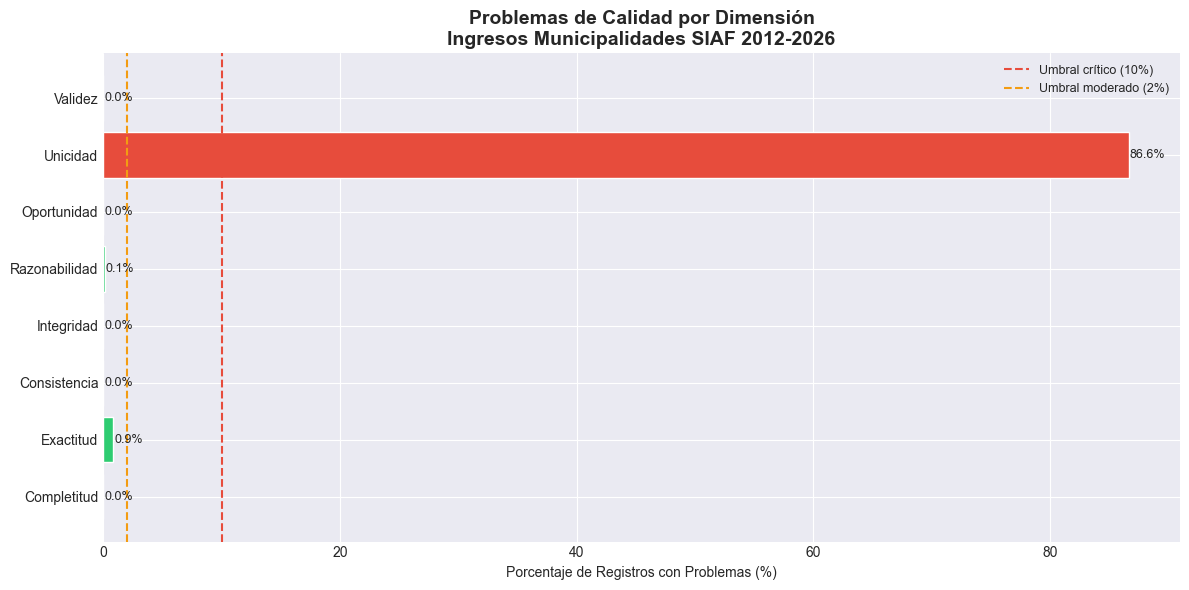

In [16]:
# REPORTE CONSOLIDADO DE CALIDAD DE DATOS - INGRESOS MUNICIPALIDADES

columnas_criticas = [
    'NIVEL_GOBIERNO', 'EJECUTORA_NOMBRE',
    'DEPARTAMENTO_EJECUTORA_NOMBRE', 'RUBRO_NOMBRE',
    'MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO'
]

df_munic = df[df['NIVEL_GOBIERNO'] == 'M'].copy()

reporte_final = pd.DataFrame({
    'Dimensión': [
        'Completitud',
        'Exactitud',
        'Consistencia',
        'Integridad',
        'Razonabilidad',
        'Oportunidad',
        'Unicidad',
        'Validez'
    ],
    'Registros con Problemas': [
        df_munic[columnas_criticas].isnull().sum().sum(),
        len(df_munic[df_munic['MONTO_PIA'] < 0]) +
        len(df_munic[df_munic['MONTO_PIM'] < 0]) +
        len(df_munic[df_munic['MONTO_RECAUDADO'] < 0]),
        len(df_munic[df_munic['NIVEL_GOBIERNO_NOMBRE'] != 'GOBIERNOS LOCALES']),
        len(df_munic[df_munic['SEC_EJEC'].isnull()]),
        len(df_munic[
            (df_munic['MONTO_PIM'] > 0) &
            ((df_munic['MONTO_RECAUDADO'] / df_munic['MONTO_PIM']) * 100 > 150)
        ]),
        len(df_munic[
            (df_munic['ANO_DOC'] < 2012) |
            (df_munic['ANO_DOC'] > 2026)
        ]),
        len(df_munic[df_munic.duplicated(
            subset=['ANO_DOC', 'MES_DOC', 'SEC_EJEC',
                    'RUBRO', 'FUENTE_FINANCIAMIENTO',
                    'GENERICA', 'SUBGENERICA'],
            keep=False
        )]),
        len(df[~df['NIVEL_GOBIERNO'].isin(['E', 'R', 'M'])])
    ]
})

reporte_final['Porcentaje'] = (
    reporte_final['Registros con Problemas'] / len(df_munic) * 100
).round(2)

reporte_final['Severidad'] = reporte_final['Porcentaje'].apply(
    lambda x: '🔴 CRÍTICO'   if x > 10
    else      ('🟡 MODERADO' if x > 2
    else       '🟢 ACEPTABLE')
)

print("=" * 65)
print("   REPORTE CONSOLIDADO DE CALIDAD DE DATOS")
print("   Ingresos Municipalidades SIAF 2012-2026")
print("=" * 65)
print(f"\nTotal registros municipalidades: {len(df_munic):,}")
print()
print(reporte_final.to_string(index=False))

puntaje = 100 - reporte_final['Porcentaje'].mean()
print(f"\n{'=' * 65}")
print(f"📊 PUNTAJE GLOBAL DE CALIDAD: {puntaje:.1f} / 100")
print(f"{'=' * 65}")

# Visualización
colores = [
    '#e74c3c' if p > 10 else '#f39c12' if p > 2 else '#2ecc71'
    for p in reporte_final['Porcentaje']
]

plt.figure(figsize=(12, 6))
bars = plt.barh(
    reporte_final['Dimensión'],
    reporte_final['Porcentaje'],
    color=colores,
    edgecolor='white'
)
plt.axvline(x=10, color='#e74c3c', linestyle='--',
            linewidth=1.5, label='Umbral crítico (10%)')
plt.axvline(x=2,  color='#f39c12', linestyle='--',
            linewidth=1.5, label='Umbral moderado (2%)')
for bar, val in zip(bars, reporte_final['Porcentaje']):
    plt.text(
        val + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        va='center', fontsize=9
    )
plt.xlabel('Porcentaje de Registros con Problemas (%)')
plt.title(
    'Problemas de Calidad por Dimensión\nIngresos Municipalidades SIAF 2012-2026',
    fontsize=14, fontweight='bold'
)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()